Introdução:

O presente relatório tem como objetivo apresentar uma análise exploratória de dados realizada a partir de uma base de resultado financeiro, utilizando a linguagem Python como ferramenta principal de processamento e visualização.

A Base A contém o histórico de resultados financeiros mensais da empresa, segmentados por categoria de receita — Crédito, Empréstimo, Investimento e Locação de Equipamentos — ao longo dos anos de 2025 e 2026. A análise desta base foi motivada pela preocupação do CEO ao observar que o resultado financeiro acumulado de 2026 se encontrava significativamente abaixo do registrado em 2025. O objetivo é investigar se essa percepção reflete uma queda real de desempenho ou se há outro fator explicativo por trás dessa diferença.

Estrutura final:
      Mes       Data   Ano                Categoria  Valor
0  jan/25 2025-01-01  2025             INVESTIMENTO     41
1  jan/25 2025-01-01  2025                  CRÉDITO    111
2  jan/25 2025-01-01  2025               EMPRÉSTIMO     48
3  jan/25 2025-01-01  2025  LOCAÇÃO DE EQUIPAMENTOS     39
4  fev/25 2025-02-01  2025             INVESTIMENTO     46
5  fev/25 2025-02-01  2025                  CRÉDITO    110
6  fev/25 2025-02-01  2025               EMPRÉSTIMO     45
7  fev/25 2025-02-01  2025  LOCAÇÃO DE EQUIPAMENTOS     40
8  mar/25 2025-03-01  2025             INVESTIMENTO     44
9  mar/25 2025-03-01  2025                  CRÉDITO    102

=== Total por Ano (Milhões R$) ===
    Ano  Valor
0  2025   2734
1  2026    372

=== Total por Ano e Categoria ===
Categoria  CRÉDITO  EMPRÉSTIMO  INVESTIMENTO  LOCAÇÃO DE EQUIPAMENTOS
Ano                                                                  
2025          1315         453           525                      441
2026    

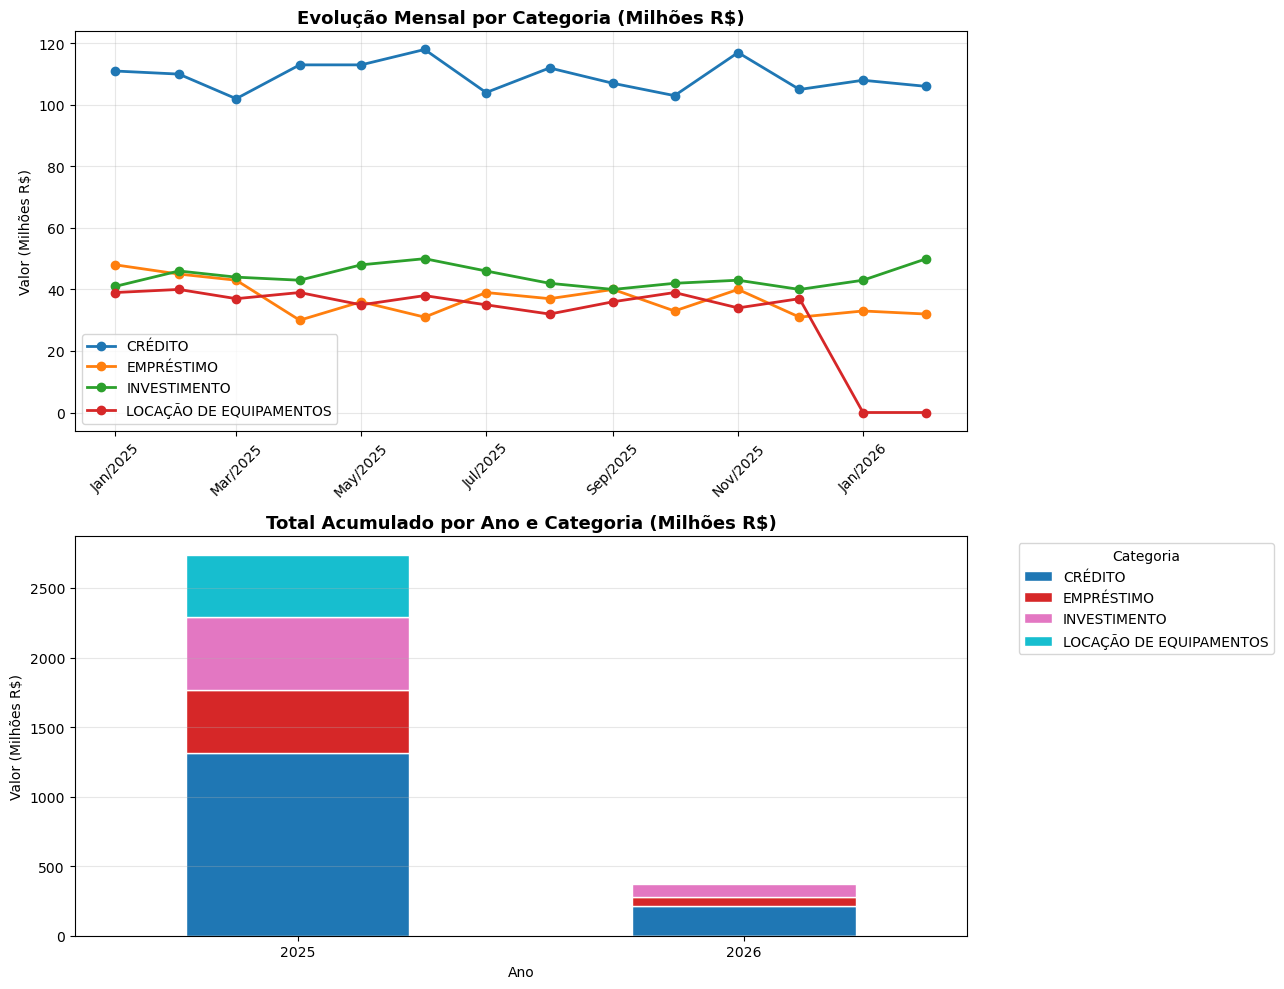

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Carregamento ---
df_a = pd.read_csv(
    'teste_lifecycleanalytics_a.csv',
    sep=';',
    header=None,
    names=['Mes', 'Categoria', 'Valor'],
    engine='python'
)

# --- Limpeza ---
df_a = df_a[df_a['Mes'] != 'Mês'].reset_index(drop=True)

df_a['Valor']     = pd.to_numeric(df_a['Valor'], errors='coerce')
df_a['Categoria'] = df_a['Categoria'].str.strip()

# --- Converter mês PT-BR para datetime ---
meses_pt = {
    'jan': 'Jan', 'fev': 'Feb', 'mar': 'Mar', 'abr': 'Apr',
    'mai': 'May', 'jun': 'Jun', 'jul': 'Jul', 'ago': 'Aug',
    'set': 'Sep', 'out': 'Oct', 'nov': 'Nov', 'dez': 'Dec'
}

def converter_mes(mes_str):
    if pd.isna(mes_str):
        return pd.NaT
    mes = str(mes_str).strip().lower()
    for pt, en in meses_pt.items():
        mes = mes.replace(pt, en)
    try:
        return pd.to_datetime(mes, format='%b/%y')
    except:
        return pd.NaT

df_a['Data'] = df_a['Mes'].apply(converter_mes)
df_a['Ano']  = df_a['Data'].dt.year

df_a = df_a.dropna(subset=['Data']).reset_index(drop=True)

print("Estrutura final:")
print(df_a[['Mes', 'Data', 'Ano', 'Categoria', 'Valor']].head(10))

# --- Análises ---
total_por_ano = df_a.groupby('Ano')['Valor'].sum().reset_index()
print("\n=== Total por Ano (Milhões R$) ===")
print(total_por_ano)

total_cat = df_a.groupby(['Ano', 'Categoria'])['Valor'].sum().unstack(fill_value=0)
print("\n=== Total por Ano e Categoria ===")
print(total_cat)

meses_por_ano = df_a.groupby('Ano')['Mes'].nunique()
print("\n=== Meses registrados por Ano ===")
print(meses_por_ano)

# --- Gráficos ---
mensal_cat = df_a.groupby(
    ['Data', 'Categoria'])['Valor'].sum().unstack(fill_value=0).sort_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Evolução mensal por categoria
for col in mensal_cat.columns:
    axes[0].plot(mensal_cat.index, mensal_cat[col], marker='o', linewidth=2, label=col)
axes[0].set_title('Evolução Mensal por Categoria (Milhões R$)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor (Milhões R$)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Barras empilhadas por ano
total_cat.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Total Acumulado por Ano e Categoria (Milhões R$)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Valor (Milhões R$)')
axes[1].set_xlabel('Ano')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('analise_base_a.png', dpi=150, bbox_inches='tight')
plt.show()

Conclusão:

Com base nos dados disponíveis, a preocupação do CEO é correta no valor absoluto, mas também equivocada na interpretação da causa. O ano de 2026 apresenta apenas dois mêses registrado (janeiro e fevereiro/2026, com R$ 372 milhões em resultado), enquanto 2025 acumula registros de múltiplos meses e categorias — Crédito, Investimento e Locação de Equipamentos.

A explicação mais provável para a discrepância não é uma queda real no desempenho, mas sim um efeito de incompletude temporal: 2026 ainda está no início do ciclo, ao passo que 2025 já possui vários meses consolidados. Comparar o acumulado de um ano quase inteiro com apenas um mês de outro ano naturalmente vai gerar essa diferença expressiva.

A recomendação ao CEO seria comparar os mesmos períodos entre os dois anos (ex: janeiro–fevereiro de 2025 vs. janeiro–fevereiro de 2026) antes de tirar conclusões sobre tendência de queda.